# Santer & Poterjoy 2026 Likelihood Estimation LPF Experiments


In [1]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood

reload(dap)

np.set_printoptions(suppress=True)


In [2]:
poep = {'mu': 0, 'sigma': 2.0} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [3]:
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd = dap.Expt('e_sd_kecd', {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 4,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2000,
                       'T_train': 100,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': 'knn_adaptive',
                       'klb':klb,
                       'debug_nle_noDA': False})
e_sd_true = dap.Expt('e_sd_true', {'expt_flag': 1,
                       'model_flag':2,
                       'localize':1,
                       'obf': 4,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 1,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep_sd,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2000,
                       })
e_sd_gaus = dap.Expt('e_sd_gaus', {'expt_flag': 1,
                       'model_flag':2,
                       'localize':1,
                       'obf': 4,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 2000})


In [4]:
dap.runDA(e_sd_kecd)
dap.runDA(e_sd_true)
dap.runDA(e_sd_gaus)

DB: Starting cycle 0
DB: Starting cycle 20
DB: Starting cycle 40
DB: Starting cycle 60
DB: Starting cycle 80
DB: Starting cycle 100
knn is: 1200, number of samples = 12000
using median distance without 0s: 0.023759919504546534
0.023759919504546534
knn is: 1200, number of samples = 12000
using median distance without 0s: 0.02345935614032993
0.02345935614032993
DB: Starting cycle 120
DB: Starting cycle 140
knn is: 1200, number of samples = 12000
using median distance without 0s: 0.023069679338826806
0.023069679338826806
knn is: 1200, number of samples = 12000
using median distance without 0s: 0.022488361611656627
0.022488361611656627
DB: Starting cycle 160
DB: Starting cycle 180
DB: Starting cycle 200
knn is: 1200, number of samples = 12000
using median distance without 0s: 0.02258498116617419
0.02258498116617419
knn is: 1200, number of samples = 12000
using median distance without 0s: 0.02228541823029684
0.02228541823029684
DB: Starting cycle 220
DB: Starting cycle 240
knn is: 1200, num

'completed'

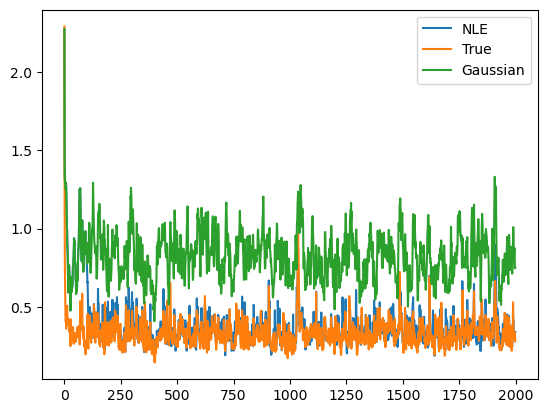

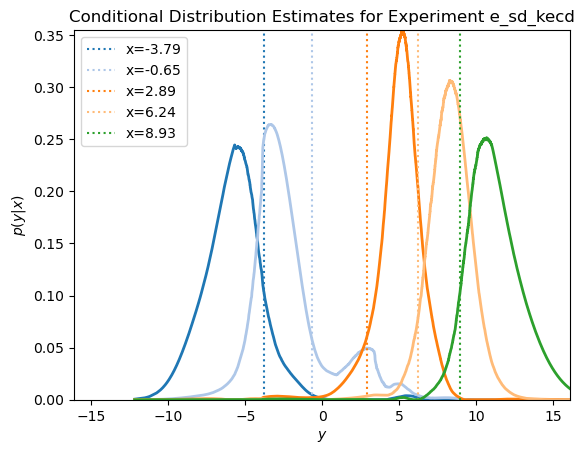

<Figure size 640x480 with 0 Axes>

In [9]:
plt.plot(e_sd_kecd.rmse, label='NLE')
plt.plot(e_sd_true.rmse, label='True')
plt.plot(e_sd_gaus.rmse, label='Gaussian')
plt.legend()
plt.show()
dap.plot_pab(e_sd_kecd, plot_states=True)

e_sd_kecd.saveExpt()
e_sd_true.saveExpt()
e_sd_gaus.saveExpt()

In [3]:
e = dap.loadExpt('cauchy-kecd.expt')
x_train = e.x_train
y_train = e.y_train
pab = e.keest_pab

In [6]:
def plot_pab(x_train, y_train, pab, ax = None, plot_states=False, pab_sample_states=-999):

      if ax is None:
            fig, ax = plt.subplots(1, 1)

      
      ys = np.sort(y_train[0, :])
      ind2 = np.argsort(y_train[0, :])
      diff = np.diff(ys)

      fig = plt.figure(31)
      plt.clf()
      cmap = plt.get_cmap('tab20')

      htp = []

      if pab_sample_states == -999:
            states = np.quantile(x_train, [0.1, 0.25, 0.5, 0.75, 0.9])
      else:
            states = pab_sample_states

      for ind, j in enumerate(states):
            dum = np.abs(j - x_train[0, :])
            ind1 = np.argsort(dum)[0]

            h = pab[ind2, ind1]

            # Normalize for plotting
            normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
            h_norm = h / normalization
            htp.append(h_norm)

            # Plotting
            ax.plot(ys, h_norm, linewidth=2, color=cmap(ind))
            if plot_states:
                  ax.axvline(x=j, color=cmap(ind), linestyle='dotted', label=f'x={j:.2f}')

      bound = max(np.abs(np.min(x_train)), np.abs(np.max(x_train)))
      ax.set_xlim([-bound, bound])
      ax.set_ylim([0, np.max(htp)])
      ax.legend()

      ax.set_title(f'Conditional Distribution Estimates for Experiment')

      ax.set_xlabel('$y$')
      ax.set_ylabel('$p(y | x)$')


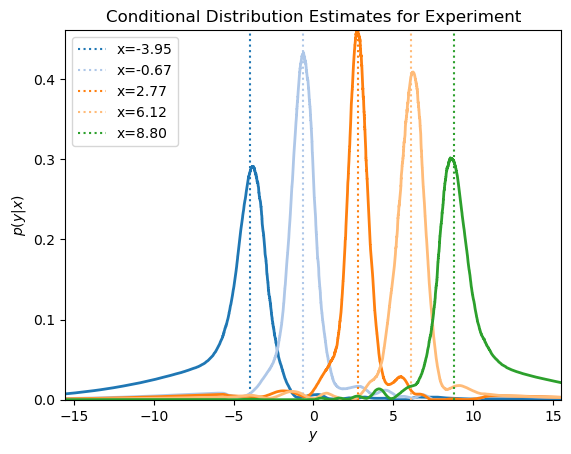

<Figure size 640x480 with 0 Axes>

In [8]:
plot_pab(x_train, y_train, pab, plot_states=True)